## We are going 3D


In [1]:
from image_processing import *
import cv2
import numpy as np

# Load and convert images to grayscale if not already
img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)

In [2]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")

In [3]:
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

print(P_left)
print(P_right)

Q = calculate_q_matrix(P_left, P_right)
print(Q)

[[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]
[[ 7.070493e+02  0.000000e+00  6.040814e+02 -3.341081e+02]
 [ 0.000000e+00  7.070493e+02  1.805066e+02  2.330660e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.201153e-03]]
[[   1.            0.            0.         -604.0814    ]
 [   0.            1.            0.         -180.5066    ]
 [   0.            0.            0.         -707.0493    ]
 [   0.            0.           -2.11622915    0.        ]]


In [4]:
from matplotlib import pyplot as plt
def plot_disparity_map(disp_map):
    """
    Plot the disparity map using Matplotlib.

    Parameters:
    - disp_map: Disparity map generated from compute_disparity_map function.
    """
    # Set the minimum and maximum disparity values for visualization
    plt.figure(figsize=(10, 7))
    plt.imshow(disp_map, cmap='plasma')
    plt.colorbar(label='Disparity Value')
    plt.title("Disparity Map")
    plt.xlabel("X-axis (pixels)")
    plt.ylabel("Y-axis (pixels)")
    plt.show()

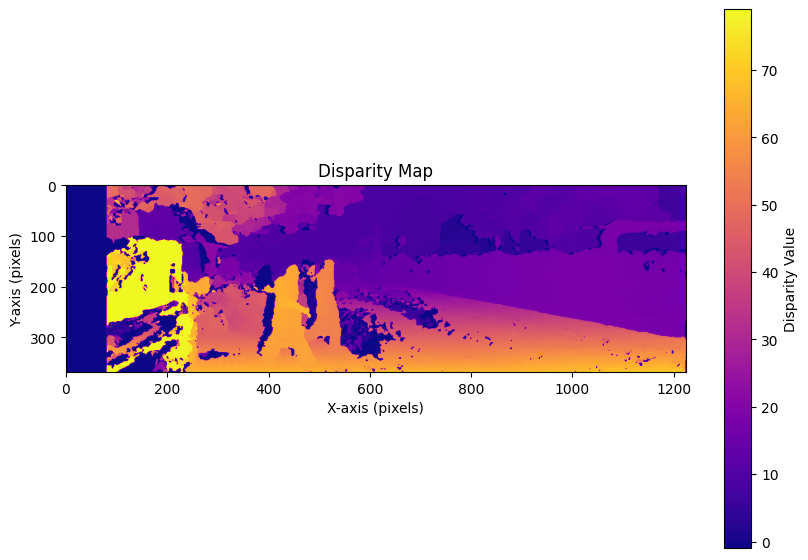

Diparity map range: -1.0 79.0


In [5]:
disp_map = compute_disparity_map(img1, img2)

plot_disparity_map(disp_map)

print(f'Diparity map range: {disp_map.min()} {disp_map.max()}')

In [10]:
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

points, colors = generate_point_cloud(disp_map, Q, color_image=color_img, max_z=20)
print(points)

[[ 4.9467907  1.7037971  6.67382  ]
 [ 4.9311953  1.7016727  6.6654983]
 [ 4.915639   1.6995535  6.6571975]
 ...
 [-4.177861  -1.2827421  4.811638 ]
 [-4.192213  -1.2850555  4.8203154]
 [-4.2104206 -1.2885412  4.83339  ]]


In [11]:
import open3d as o3d


def visualize_point_cloud(points, colors=None):
    """
    Visualize a 3D point cloud with optional RGB colors using Open3D.
    
    Parameters:
    - points: (N, 3) numpy array of 3D points.
    - colors: (N, 3) numpy array of RGB colors corresponding to each point, with values in [0, 255].
    """
    # Create an Open3D PointCloud object
    point_cloud = o3d.geometry.PointCloud()

    # Assign points directly to the point cloud
    point_cloud.points = o3d.utility.Vector3dVector(points)
    
    # Normalize colors to [0, 1] and assign if available
    if colors is not None:
        point_cloud.colors = o3d.utility.Vector3dVector(colors / 255.0)

    # Visualize the point cloud with all points, including any invalid depths
    o3d.visualization.draw_geometries([point_cloud], window_name="3D Point Cloud Visualization (All Points)")



In [12]:
print(points.max())
print(points.min())

19.946753
-17.460474


In [ ]:


# Visualize
visualize_point_cloud(points, colors)



[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
